<a href="https://colab.research.google.com/github/ElizaChurokova/ds-agroscan-plant-pathology-dataset-project/blob/main/%2203_Plant_Disease_ResNet50_EfficientNetB0_Model_Comparison_02122026%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Модель ResNet50

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as resnet_preprocess

# 1. Специфичный генератор для ResNet
datagen_res = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_res = datagen_res.flow_from_directory(base_path + 'train', target_size=(224, 224), batch_size=32, class_mode='categorical')
val_gen_res = datagen_res.flow_from_directory(base_path + 'val', target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

# 2. Архитектура ResNet50
base_model_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_res.trainable = True

model_res = models.Sequential([
    base_model_res,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(5, activation='softmax')
])

model_res.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Сохранение под новым именем
checkpoint_res = ModelCheckpoint('/content/drive/MyDrive/resnet50_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

# 4. Обучение
history_res = model_res.fit(train_gen_res, validation_data=val_gen_res, epochs=12, callbacks=[checkpoint_res, early_stop])

Found 4400 images belonging to 5 classes.
Found 550 images belonging to 5 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6987 - loss: 0.7708
Epoch 1: val_accuracy improved from -inf to 0.87455, saving model to /content/drive/MyDrive/resnet50_model.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 455s 3s/step - accuracy: 0.6997 - loss: 0.7687 - val_accuracy: 0.8745 - val_loss: 0.5716
Epoch 2/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9757 - loss: 0.0847
Epoch 2: val_accuracy improved from 0.87455 to 0.92000, saving model to /content/drive/MyDrive/resnet50_model.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9757 - loss: 0.0846 - val_accuracy: 0.9200 - val_loss: 0.2418
Epoch 3/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9854 - loss: 0.0500
Epoch 3: val_accuracy improved from 0.92000 to 0.94364, saving model to /content/drive/MyDrive/resnet50_model.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 372s 3s/step - accuracy: 0.9854 - loss: 0.0499 - val_accuracy: 0.9436 - val_loss: 0.2346
Epoch 4/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/

Accuracy-loss of ResNet50

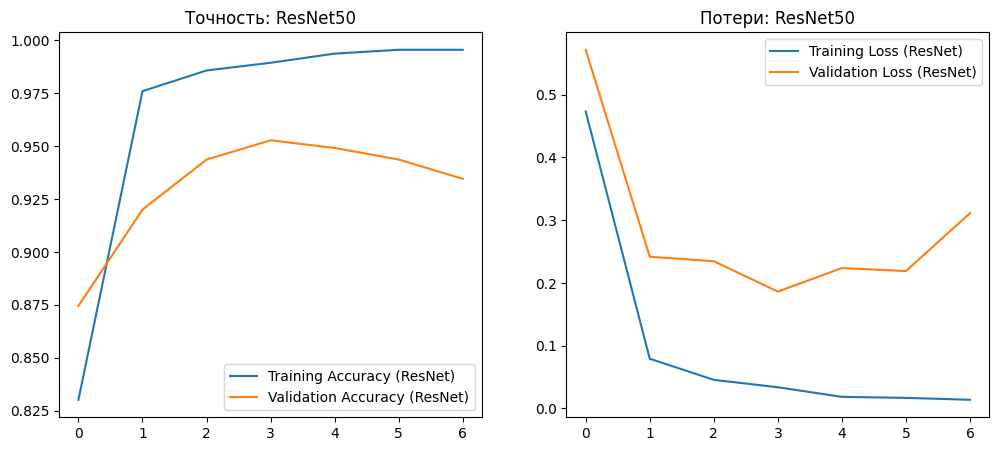


--- ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ (ResNet50) ---
18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
                    precision    recall  f1-score   support

frog_eye_leaf_spot       0.95      0.98      0.96       110
           healthy       0.92      0.97      0.95       110
    powdery_mildew       0.95      0.94      0.94       110
              rust       0.99      0.99      0.99       110
              scab       0.95      0.88      0.92       110

          accuracy                           0.95       550
         macro avg       0.95      0.95      0.95       550
      weighted avg       0.95      0.95      0.95       550


Соответствие индексов и названий:
{'frog_eye_leaf_spot': 0, 'healthy': 1, 'powdery_mildew': 2, 'rust': 3, 'scab': 4}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Графики точности и потерь для ResNet50
acc_res = history_res.history['accuracy']
val_acc_res = history_res.history['val_accuracy']
loss_res = history_res.history['loss']
val_loss_res = history_res.history['val_loss']
epochs_range = range(len(acc_res))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_res, label='Training Accuracy (ResNet)')
plt.plot(epochs_range, val_acc_res, label='Validation Accuracy (ResNet)')
plt.title('Точность: ResNet50')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_res, label='Training Loss (ResNet)')
plt.plot(epochs_range, val_loss_res, label='Validation Loss (ResNet)')
plt.title('Потери: ResNet50')
plt.legend(loc='upper right')
plt.show()

# 2. Метрики и Матрица ошибок
print("\n--- ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ (ResNet50) ---")
val_gen_res.reset()
Y_pred_res = model_res.predict(val_gen_res)
y_pred_res = np.argmax(Y_pred_res, axis=1)

print(classification_report(val_gen_res.classes, y_pred_res, target_names=list(val_gen_res.class_indices.keys())))

# 3. Вывод меток классов
print("\nСоответствие индексов и названий:")
print(val_gen_res.class_indices)

Confusion Matrix- ResNet50

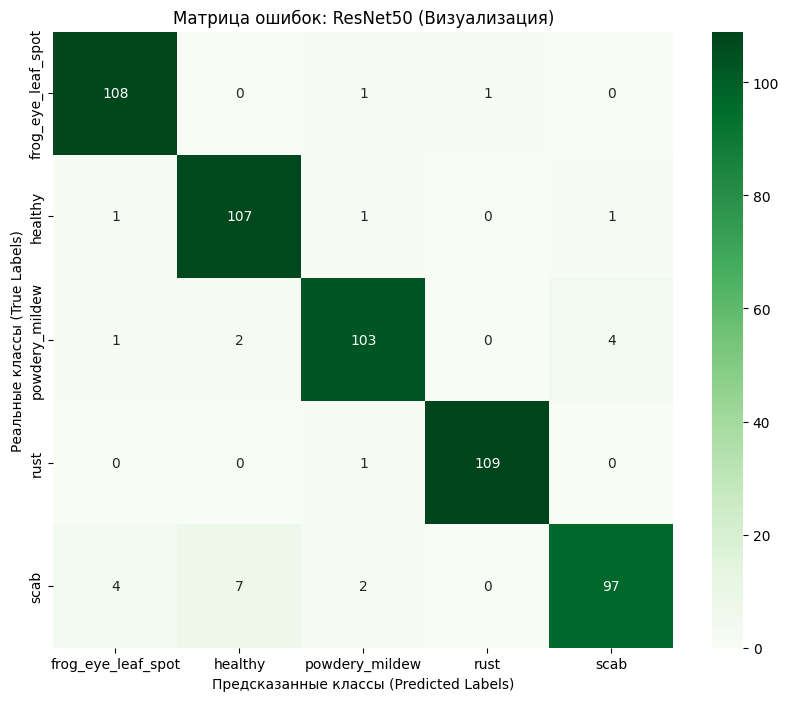

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Рассчет матрицы ошибок
cm_res = confusion_matrix(val_gen_res.classes, y_pred_res)

# 2. Настройка размера и стили
plt.figure(figsize=(10, 8))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(val_gen_res.class_indices.keys()),
            yticklabels=list(val_gen_res.class_indices.keys()))

plt.title('Матрица ошибок: ResNet50 (Визуализация)')
plt.ylabel('Реальные классы (True Labels)')
plt.xlabel('Предсказанные классы (Predicted Labels)')
plt.show()

EfficientNet - Модель

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# 1. Генераторы данных специально для EfficientNet
datagen_eff = ImageDataGenerator(preprocessing_function=eff_preprocess)

train_gen_eff = datagen_eff.flow_from_directory(base_path + 'train', target_size=(224, 224), batch_size=32, class_mode='categorical')
val_gen_eff = datagen_eff.flow_from_directory(base_path + 'val', target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

# 2. Архитектура модели
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = True # Разрешаем дообучение всей сети

model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(5, activation='softmax')
])

model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Сохранение
checkpoint_eff = ModelCheckpoint('/content/drive/MyDrive/efficientnetB0_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

# 4. Обучение
history_eff = model_eff.fit(train_gen_eff, validation_data=val_gen_eff, epochs=12, callbacks=[checkpoint_eff, early_stop])

Found 4400 images belonging to 5 classes.
Found 550 images belonging to 5 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5174 - loss: 1.2327
Epoch 1: val_accuracy improved from -inf to 0.83455, saving model to /content/drive/MyDrive/efficientnetB0_model.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 509s 3s/step - accuracy: 0.5186 - loss: 1.2303 - val_accuracy: 0.8345 - val_loss: 0.4413
Epoch 2/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8936 - loss: 0.3311
Epoch 2: val_accuracy improved from 0.83455 to 0.94909, saving model to /content/drive/MyDrive/efficientnetB0_model.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.8938 - loss: 0.3307 - val_accuracy: 0.9491 - val_loss: 0.1858
Epoch 3/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9500 - loss: 0.1528
Epoch 3: val_accuracy did not improve from 0.94909
138/138 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.9500 - loss: 0.1527 - val_accuracy: 0.9455 - val_loss: 0.1679
Epoch 4/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9798 - loss: 0.0826
Epoch 4: val_a

Confision Matrix - EfficientNet_B0

18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step


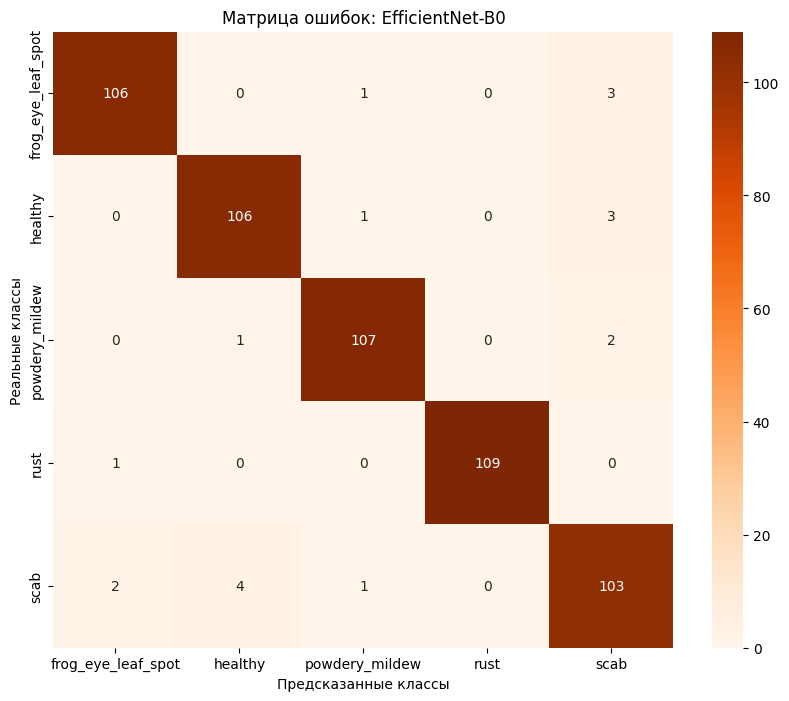


--- ДЕТАЛЬНЫЕ МЕТРИКИ EFFICIENTNET-B0 ---
                    precision    recall  f1-score   support

frog_eye_leaf_spot       0.97      0.96      0.97       110
           healthy       0.95      0.96      0.96       110
    powdery_mildew       0.97      0.97      0.97       110
              rust       1.00      0.99      1.00       110
              scab       0.93      0.94      0.93       110

          accuracy                           0.97       550
         macro avg       0.97      0.97      0.97       550
      weighted avg       0.97      0.97      0.97       550



In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Получаем предсказания
val_gen_eff.reset()
Y_pred_eff = model_eff.predict(val_gen_eff)
y_pred_eff = np.argmax(Y_pred_eff, axis=1)

# 2. Матрица ошибок
cm_eff = confusion_matrix(val_gen_eff.classes, y_pred_eff)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Oranges', # Оранжевый цвет для EfficientNet
            xticklabels=list(val_gen_eff.class_indices.keys()),
            yticklabels=list(val_gen_eff.class_indices.keys()))

plt.title('Матрица ошибок: EfficientNet-B0')
plt.ylabel('Реальные классы')
plt.xlabel('Предсказанные классы')
plt.show()

# 3. Детальные метрики (Precision, Recall, F1)
print("\n--- ДЕТАЛЬНЫЕ МЕТРИКИ EFFICIENTNET-B0 ---")
print(classification_report(val_gen_eff.classes, y_pred_eff,
                            target_names=list(val_gen_eff.class_indices.keys())))

In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем финальные версии моделей

models_to_compare = {
    "VGG16": "vgg16_model.keras",
    "ResNet50": "resnet50_model.keras",
    "InceptionV3 (Final)": "new_inceptionnetV3.keras"
}

results = []

for name, filename in models_to_compare.items():
    path = f"/content/drive/MyDrive/{filename}"
    print(f"Оценка модели {name}...")

    model = tf.keras.models.load_model(path)
    # Используем val_gen, который уже создан
    loss, acc = model.evaluate(val_gen, verbose=0)

    results.append({"Model": name, "Accuracy": acc})

# 2. Визуализация
df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=df, palette='magma')
plt.title('Сравнение точности финальных моделей на валидационном наборе')
plt.ylim(0.7, 1.0) # Масштаб для наглядности

# Добавляем цифры над столбиками
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

In [ ]:
print(train_gen.class_indices)

{'frog_eye_leaf_spot': 0, 'healthy': 1, 'powdery_mildew': 2, 'rust': 3, 'scab': 4}


Comparison of val_accuracy and val_loss of 3 models: InceptionV3, ResNet50, EfficientNet_B0

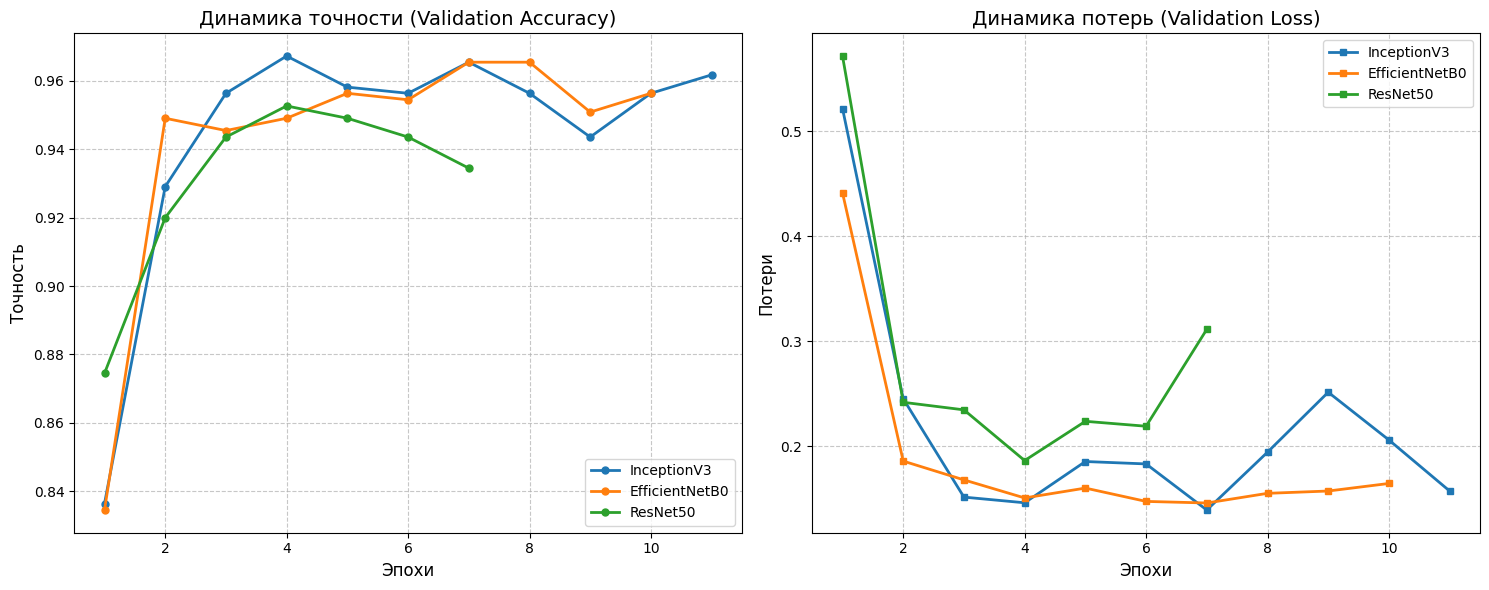


--- ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА ---
        Модель Макс. точность Мин. потери  Всего эпох
   InceptionV3       96.7300%      0.1392          11
EfficientNetB0       96.5500%      0.1459          10
      ResNet50       95.2700%      0.1863           7


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1.
# Данные InceptionV3
history_inc = {
    'val_accuracy': [0.8364, 0.9291, 0.9564, 0.9673, 0.9582, 0.9564, 0.9655, 0.9564, 0.9436, 0.9564, 0.9618],
    'val_loss': [0.5216, 0.2452, 0.1515, 0.1461, 0.1854, 0.1831, 0.1392, 0.1943, 0.2514, 0.2059, 0.1573]
}

# Данные EfficientNetB0
history_eff = {
    'val_accuracy': [0.8345, 0.9491, 0.9455, 0.9491, 0.9564, 0.9545, 0.9655, 0.9655, 0.9509, 0.9564],
    'val_loss': [0.4413, 0.1858, 0.1679, 0.1507, 0.1601, 0.1474, 0.1459, 0.1551, 0.1573, 0.1645]
}

# Данные ResNet50
history_res = {
    'val_accuracy': [0.8745, 0.9200, 0.9436, 0.9527, 0.9491, 0.9436, 0.9345],
    'val_loss': [0.5716, 0.2418, 0.2346, 0.1863, 0.2237, 0.2190, 0.3113]
}

history_dict = {
    'InceptionV3': history_inc,
    'EfficientNetB0': history_eff,
    'ResNet50': history_res
}

# 2. График
plt.figure(figsize=(15, 6))

# График Accuracy
plt.subplot(1, 2, 1)
for name, hist in history_dict.items():
    epochs = range(1, len(hist['val_accuracy']) + 1)
    plt.plot(epochs, hist['val_accuracy'], '-o', label=name, markersize=5, linewidth=2)
plt.title('Динамика точности (Validation Accuracy)', fontsize=14)
plt.xlabel('Эпохи', fontsize=12)
plt.ylabel('Точность', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# График Loss
plt.subplot(1, 2, 2)
for name, hist in history_dict.items():
    epochs = range(1, len(hist['val_loss']) + 1)
    plt.plot(epochs, hist['val_loss'], '-s', label=name, markersize=5, linewidth=2)
plt.title('Динамика потерь (Validation Loss)', fontsize=14)
plt.xlabel('Эпохи', fontsize=12)
plt.ylabel('Потери', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 3. Аналитическая таблица
results = []
for name, hist in history_dict.items():
    results.append({
        'Модель': name,
        'Макс. точность': f"{max(hist['val_accuracy']):.4%}",
        'Мин. потери': f"{min(hist['val_loss']):.4f}",
        'Всего эпох': len(hist['val_accuracy'])
    })

print("\n--- ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА ---")
print(pd.DataFrame(results).to_string(index=False))

Samples from the dataset

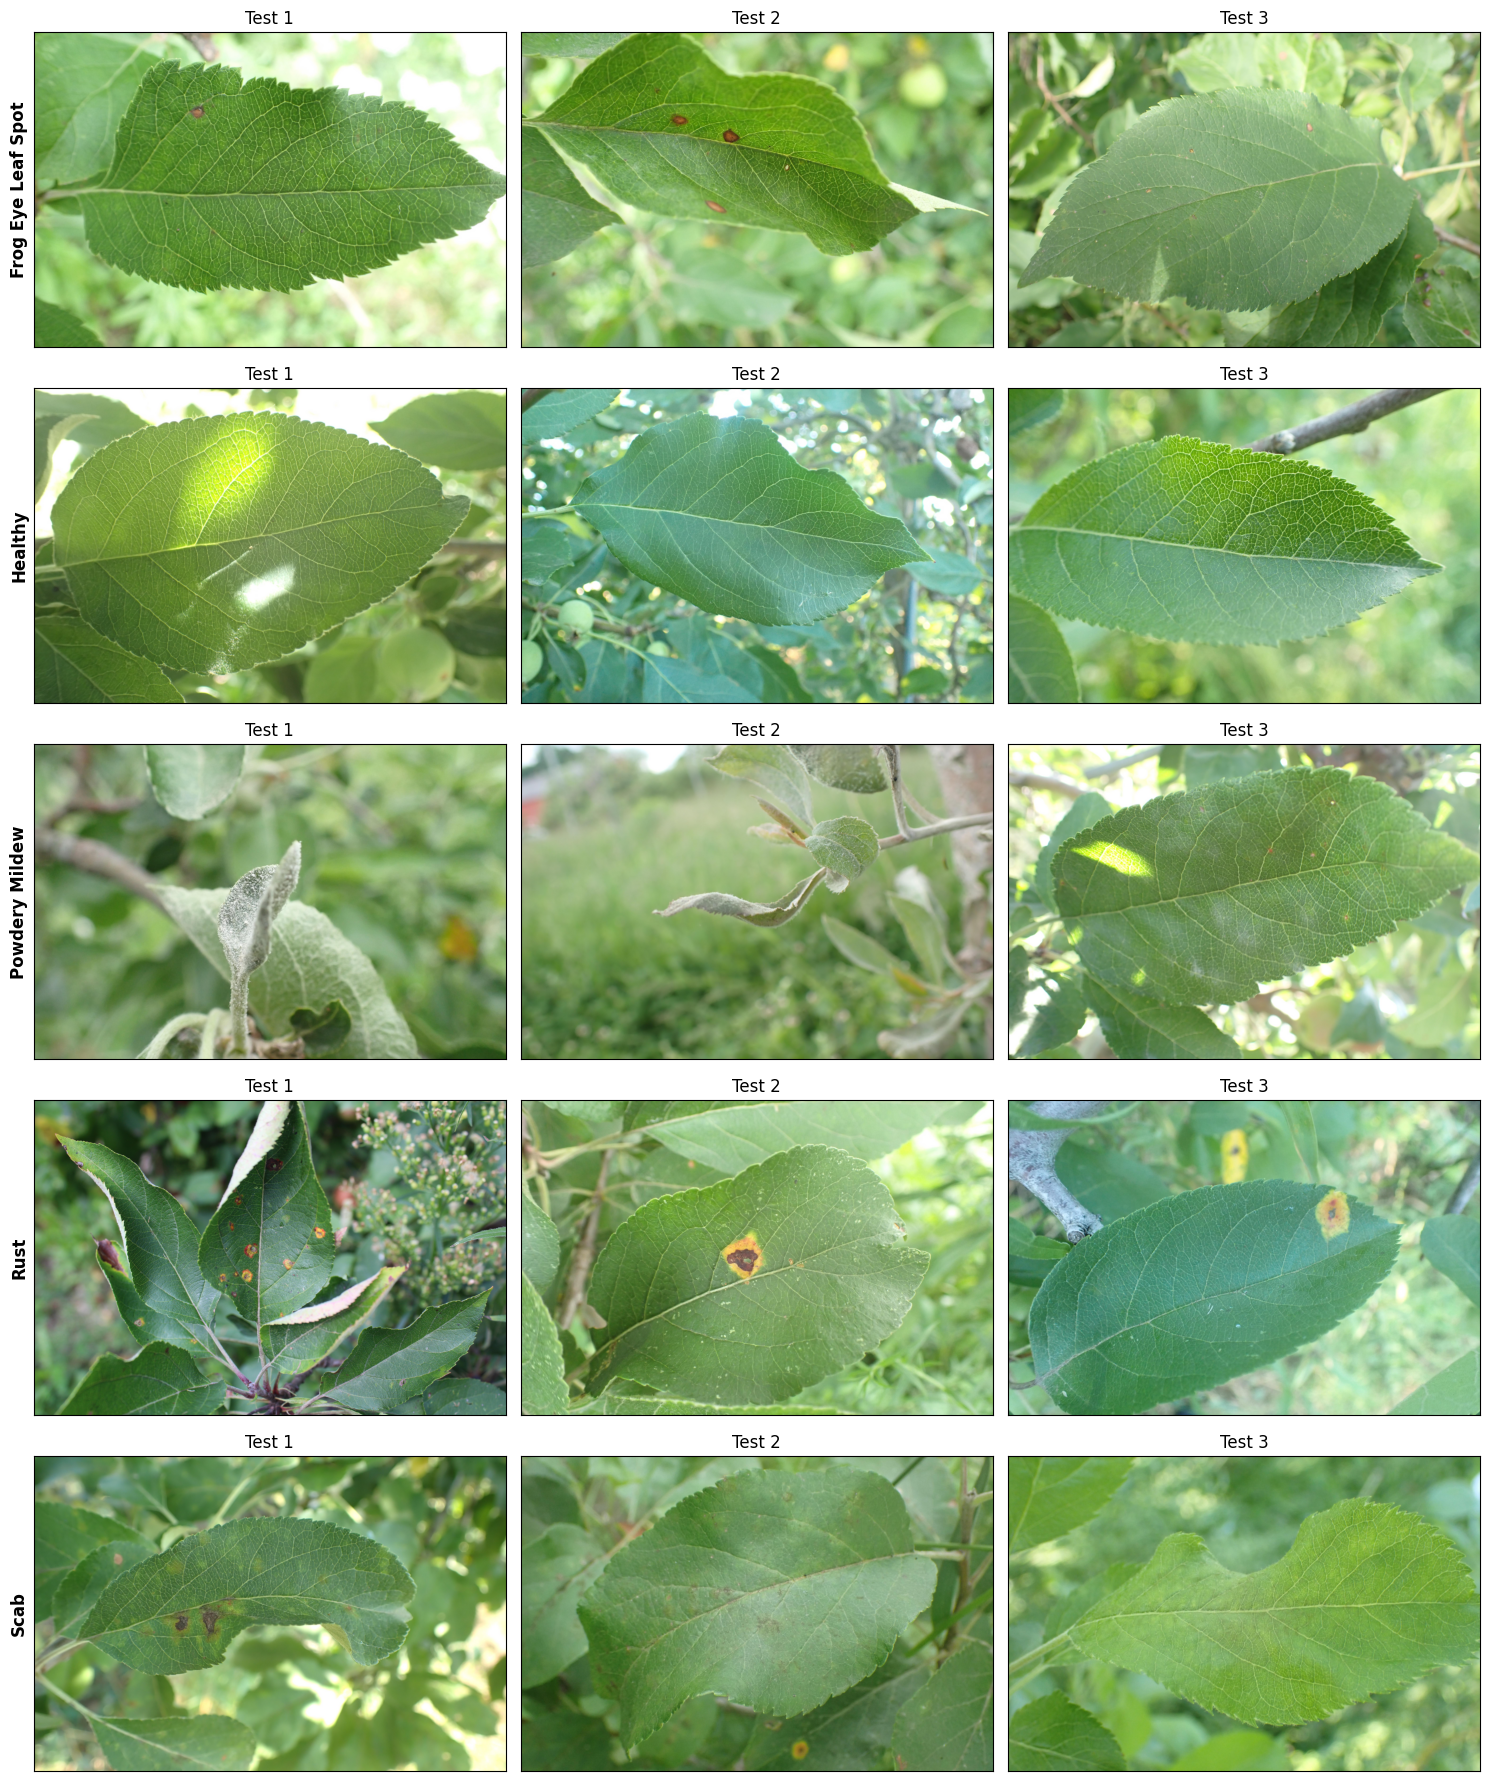

In [ ]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# Путь к тестовой папке
test_dir = '/content/drive/MyDrive/plant_dataset_split/test'
classes = ['frog_eye_leaf_spot', 'healthy', 'powdery_mildew', 'rust', 'scab']

# Сетка 5 строк на 3 столбца
fig, axes = plt.subplots(5, 3, figsize=(15, 18))

for i, label in enumerate(classes):
    class_path = os.path.join(test_dir, label)

    if os.path.exists(class_path):
        all_images = os.listdir(class_path)
        # Берем 3 случайных фото
        sample_images = random.sample(all_images, 3)

        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            ax = axes[i, j]
            ax.imshow(img)

            if j == 0:
                ax.set_ylabel(label.replace('_', ' ').title(), fontsize=12, fontweight='bold')

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"Test {j+1}")
    else:
        print(f"Папка {label} не найдена!")

plt.tight_layout()
plt.show()